# 📡 Amostragem e Aliasing com Python
por: **Iury Coelho**

Este notebook estuda a **amostragem** de sinais contínuos e o fenômeno do
**aliasing**, através de implementação e visualização em Python. Partimos do
sinal contínuo, chegamos ao **Teorema da Amostragem de Nyquist–Shannon**,
visualizamos a **replicação espectral**, reconstruímos o sinal por
**interpolação *sinc*** e terminamos com um exemplo **audível**.

#### Conteúdo
* [1. Da forma contínua à discreta](#1)
* [2. Teorema de Nyquist–Shannon](#2)
* [3. Aliasing: a frequência impostora](#3)
* [4. Visão espectral](#4)
* [5. Reconstrução do sinal](#5)
* [6. Aliasing audível](#6)
* [7. Exercícios](#7)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

<a id="1"></a>
## 1. Da forma contínua à discreta

> __Definição__
> Amostrar um sinal contínuo $x(t)$ significa registrar seu valor apenas em
> instantes igualmente espaçados $t = nT$, com $n \in \mathbb{Z}$. O resultado
> é a sequência discreta
> $$ x[n] = x(nT), \qquad n = 0, 1, 2, \dots $$
> onde $T$ é o **período de amostragem** e $f_s = 1/T$ é a **taxa (ou
> frequência) de amostragem**, em amostras por segundo (Hz).

Na prática nunca temos o sinal "contínuo" no computador: o que chamamos de
contínuo abaixo é apenas uma amostragem muito densa. O ponto é comparar uma
representação densa com uma amostragem grosseira.

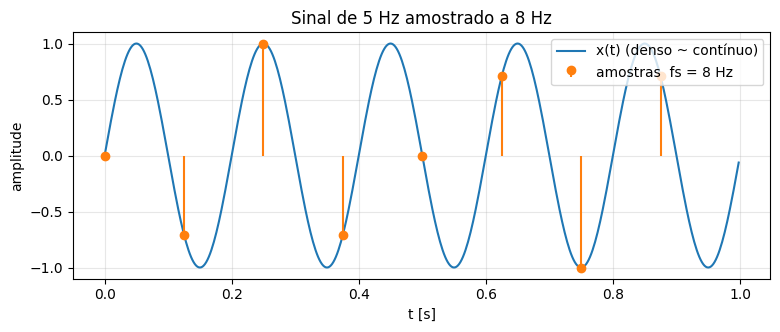

In [2]:
f = 5                      # Hz - frequencia do sinal
fs_denso = 500             # Hz - amostragem densa (aproxima o "continuo")
fs = 8                     # Hz - amostragem grosseira

t = np.arange(0, 1, 1/fs_denso)
x = np.sin(2*np.pi*f*t)

n = np.arange(0, 1, 1/fs)        # instantes de amostragem
xs = np.sin(2*np.pi*f*n)         # x[n] = x(nT)

plt.plot(t, x, label="x(t) (denso ~ contínuo)")
plt.stem(n, xs, linefmt="C1-", markerfmt="C1o", basefmt=" ",
         label=f"amostras  fs = {fs} Hz")
plt.title(f"Sinal de {f} Hz amostrado a {fs} Hz")
plt.xlabel("t [s]"); plt.ylabel("amplitude"); plt.legend(loc="upper right")
plt.show()

<a id="2"></a>
## 2. Teorema de Nyquist–Shannon

> __Teorema__
> Um sinal de banda limitada, cuja maior componente de frequência é $f_{max}$,
> pode ser **perfeitamente reconstruído** a partir de suas amostras se, e
> somente se, a taxa de amostragem satisfizer
> $$ f_s \;\ge\; 2\,f_{max}. $$

A frequência $f_s/2$ é chamada **frequência de Nyquist**. Componentes acima
dela não podem ser representadas sem ambiguidade. Veja o contraste entre
amostrar a **mesma senoide de 9 Hz** com $f_s = 50$ Hz (suficiente) e com
$f_s = 11$ Hz (insuficiente: $f_s/2 = 5{,}5 < 9$).

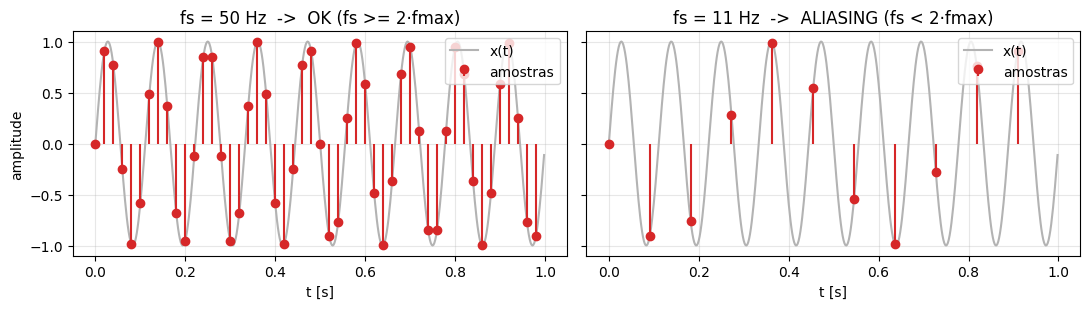

In [3]:
f = 9
t = np.arange(0, 1, 1/500)
x = np.sin(2*np.pi*f*t)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, fs in zip(axs, [50, 11]):
    n = np.arange(0, 1, 1/fs)
    ax.plot(t, x, color="0.7", label="x(t)")
    ax.stem(n, np.sin(2*np.pi*f*n), linefmt="C3-", markerfmt="C3o",
            basefmt=" ", label="amostras")
    suf = "OK (fs >= 2·fmax)" if fs >= 2*f else "ALIASING (fs < 2·fmax)"
    ax.set_title(f"fs = {fs} Hz  ->  {suf}")
    ax.set_xlabel("t [s]"); ax.legend(loc="upper right")
axs[0].set_ylabel("amplitude")
plt.tight_layout(); plt.show()

<a id="3"></a>
## 3. Aliasing: a frequência impostora

Quando $f_s < 2f$, a senoide amostrada se confunde com outra de frequência
**mais baixa**: é o *aliasing*. A frequência aparente (o "alias") observada na
faixa $[0,\, f_s/2]$ é obtida por **dobramento** (*folding*):

$$ f_{ap} = \left|\, f - k\,f_s \,\right|, \qquad k = \operatorname{round}(f/f_s). $$

In [4]:
def freq_aparente(f, fs):
    # frequencia observada (0..fs/2) ao amostrar um tom de f Hz a fs Hz
    k = np.round(f / fs)
    return np.abs(f - k*fs)

fs = 20
print(f"fs = {fs} Hz  ->  Nyquist = {fs/2} Hz")
for f in [2, 8, 12, 18, 22]:
    print(f"  f = {f:>2} Hz   alias = {freq_aparente(f, fs):>4.1f} Hz")

fs = 20 Hz  ->  Nyquist = 10.0 Hz
  f =  2 Hz   alias =  2.0 Hz
  f =  8 Hz   alias =  8.0 Hz
  f = 12 Hz   alias =  8.0 Hz
  f = 18 Hz   alias =  2.0 Hz
  f = 22 Hz   alias =  2.0 Hz


__Verificação visual__: um tom de **18 Hz** amostrado a **20 Hz** produz
exatamente as mesmas amostras que um tom de **2 Hz** — eles são
indistinguíveis depois de amostrados.

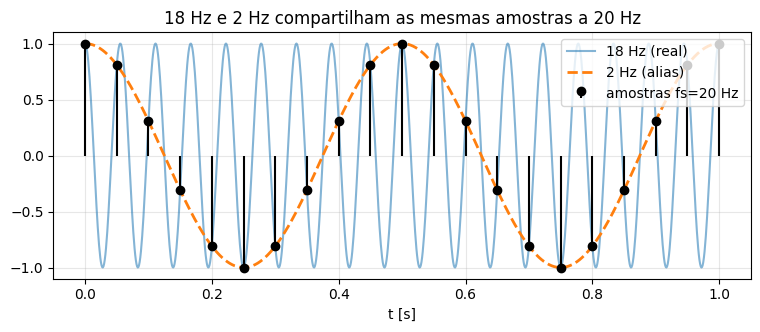

In [5]:
fs = 20
f_real, f_alias = 18, freq_aparente(18, fs)   # 2 Hz
t = np.linspace(0, 1, 1000)
n = np.arange(0, 1 + 1e-9, 1/fs)

plt.plot(t, np.cos(2*np.pi*f_real*t),  "C0",  alpha=.55, label=f"{f_real} Hz (real)")
plt.plot(t, np.cos(2*np.pi*f_alias*t), "C1--", lw=2, label=f"{f_alias:.0f} Hz (alias)")
plt.stem(n, np.cos(2*np.pi*f_real*n), linefmt="k-", markerfmt="ko",
         basefmt=" ", label=f"amostras fs={fs} Hz")
plt.title("18 Hz e 2 Hz compartilham as mesmas amostras a 20 Hz")
plt.xlabel("t [s]"); plt.legend(loc="upper right"); plt.show()

A curva de dobramento mostra como **qualquer** frequência de entrada é mapeada
para a faixa $[0, f_s/2]$. O padrão em ziguezague é a "assinatura" do aliasing.

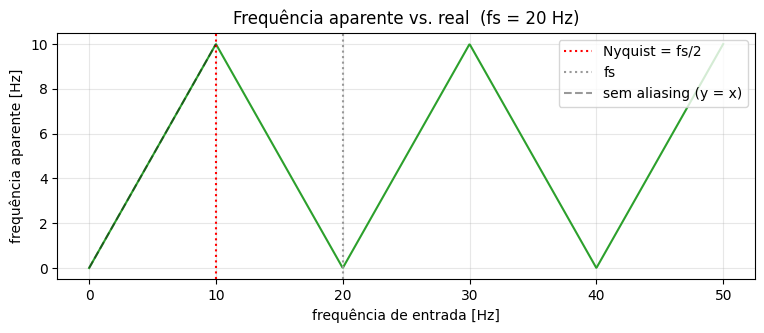

In [6]:
fs = 20
f_in = np.linspace(0, 2.5*fs, 1000)
f_out = np.array([freq_aparente(f, fs) for f in f_in])

plt.plot(f_in, f_out, "C2")
plt.axvline(fs/2, color="r", ls=":", label="Nyquist = fs/2")
plt.axvline(fs,   color="0.6", ls=":", label="fs")
plt.plot([0, fs/2], [0, fs/2], "k--", alpha=.4, label="sem aliasing (y = x)")
plt.title(f"Frequência aparente vs. real  (fs = {fs} Hz)")
plt.xlabel("frequência de entrada [Hz]"); plt.ylabel("frequência aparente [Hz]")
plt.legend(loc="upper right"); plt.show()

<a id="4"></a>
## 4. Visão espectral

No domínio da frequência, amostrar **replica** o espectro do sinal a cada
múltiplo de $f_s$. Se $f_s \ge 2f_{max}$ as réplicas não se tocam e o espectro
original é recuperável; se $f_s < 2f_{max}$ as réplicas **se sobrepõem** e
componentes "dobram" para dentro da banda — exatamente o aliasing.

Abaixo, um sinal com componentes em **5, 12 e 18 Hz** é amostrado a
$f_s = 50$ Hz (sem aliasing) e a $f_s = 30$ Hz (com aliasing: o componente de
18 Hz cai sobre $|18-30| = 12$ Hz).

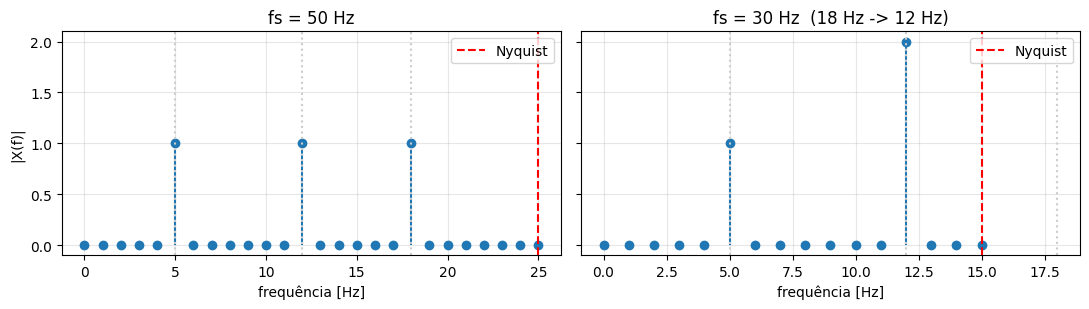

In [7]:
def espectro(x, fs):
    # amplitude de um sinal real via rFFT
    X = np.abs(np.fft.rfft(x)) / len(x) * 2
    freqs = np.fft.rfftfreq(len(x), 1/fs)
    return freqs, X

componentes = [5, 12, 18]
dur = 1.0

fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, fs in zip(axs, [50, 30]):
    n = np.arange(0, dur, 1/fs)
    x = sum(np.cos(2*np.pi*fc*n) for fc in componentes)
    fr, X = espectro(x, fs)
    ax.stem(fr, X, basefmt=" ")
    for fc in componentes:
        ax.axvline(fc, color="0.8", ls=":")
    ax.axvline(fs/2, color="r", ls="--", label="Nyquist")
    ax.set_title(f"fs = {fs} Hz" + ("" if fs >= 2*max(componentes) else "  (18 Hz -> 12 Hz)"))
    ax.set_xlabel("frequência [Hz]"); ax.legend(loc="upper right")
axs[0].set_ylabel("|X(f)|")
plt.tight_layout(); plt.show()

<a id="5"></a>
## 5. Reconstrução do sinal

Quando a condição de Nyquist é respeitada, o sinal contínuo é recuperado pela
**fórmula de interpolação de Whittaker–Shannon**, somando funções *sinc*
deslocadas e ponderadas pelas amostras:

$$ x(t) = \sum_{n} x[n]\; \operatorname{sinc}\!\left(\frac{t - nT}{T}\right),
\qquad \operatorname{sinc}(a) = \frac{\sin(\pi a)}{\pi a}. $$

erro máximo de reconstrução: 0.22161124464761983


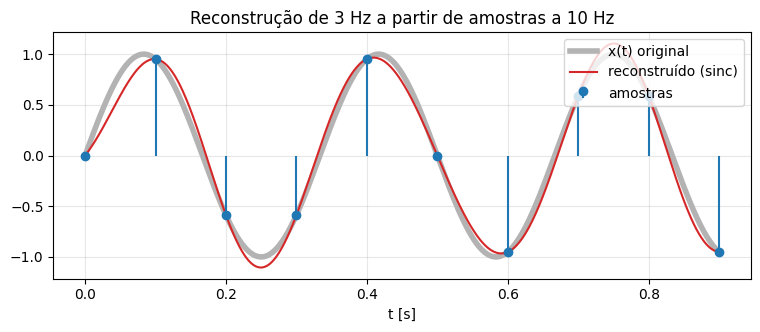

In [8]:
def reconstrucao_sinc(amostras, fs, t):
    # interpolacao de Whittaker-Shannon
    Ts = 1/fs
    n = np.arange(len(amostras))
    y = np.zeros_like(t, dtype=float)
    for ni, ak in zip(n, amostras):
        y += ak * np.sinc((t - ni*Ts) / Ts)
    return y

f, fs = 3, 10                      # 3 Hz amostrado a 10 Hz (fs > 2f -> OK)
n = np.arange(0, 1, 1/fs)
amostras = np.sin(2*np.pi*f*n)

t = np.linspace(0, 0.9, 1000)
x_orig = np.sin(2*np.pi*f*t)
x_rec = reconstrucao_sinc(amostras, fs, t)

plt.plot(t, x_orig, "0.7", lw=4, label="x(t) original")
plt.plot(t, x_rec, "C3", label="reconstruído (sinc)")
plt.stem(n, amostras, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="amostras")
plt.title(f"Reconstrução de {f} Hz a partir de amostras a {fs} Hz")
plt.xlabel("t [s]"); plt.legend(loc="upper right")
print("erro máximo de reconstrução:", np.max(np.abs(x_orig - x_rec)))
plt.show()

<a id="6"></a>
## 6. Aliasing audível

Nada como **ouvir** o efeito. Geramos um *sweep* (varredura) cuja frequência
sobe linearmente de 100 Hz a 6000 Hz, amostrado a $f_s = 8000$ Hz
($f_s/2 = 4000$ Hz). Quando a frequência instantânea ultrapassa 4000 Hz, ela
**dobra de volta** e o tom passa a *descer* — você ouve a subida virar
descida. Esse é o aliasing acontecendo no áudio.

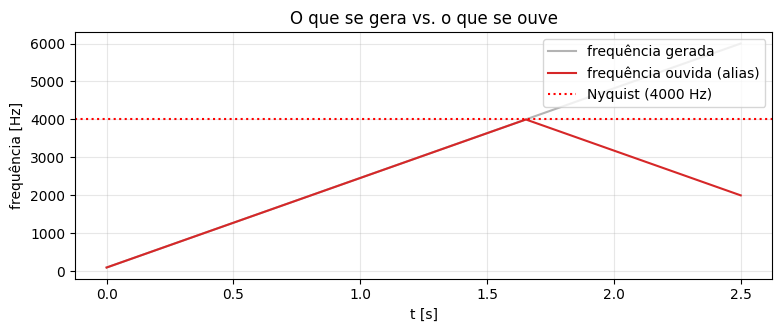

In [9]:
fs_audio = 8000
dur = 2.5
t = np.linspace(0, dur, int(fs_audio*dur), endpoint=False)

f0, f1 = 100, 6000                       # f1 > fs/2 => aliasing audivel
inst = f0 + (f1 - f0) * t / dur          # frequencia instantanea
fase = 2*np.pi*np.cumsum(inst)/fs_audio
sweep = 0.3*np.sin(fase)

# frequencia aparente teorica (folding) ao longo do tempo
ap = np.where(inst <= fs_audio/2, inst, fs_audio - inst)
plt.plot(t, inst, "0.7", label="frequência gerada")
plt.plot(t, ap, "C3", label="frequência ouvida (alias)")
plt.axhline(fs_audio/2, color="r", ls=":", label="Nyquist (4000 Hz)")
plt.title("O que se gera vs. o que se ouve")
plt.xlabel("t [s]"); plt.ylabel("frequência [Hz]"); plt.legend(loc="upper right")
plt.show()

display(Audio(sweep, rate=fs_audio))

<a id="7"></a>
## 7. Exercícios

__Exercício 1__ — O sinal $x(t) = \cos(2\pi\,1000\,t) + \cos(2\pi\,1500\,t)$ é
amostrado a $f_s = 1800$ Hz. Há aliasing? Quais as frequências aparentes?

In [10]:
fs = 1800
for f in [1000, 1500]:
    fa = freq_aparente(f, fs)
    flag = "ALIASING" if f > fs/2 else "ok"
    print(f"f = {f} Hz  ->  alias = {fa:.0f} Hz   [{flag}]")

f = 1000 Hz  ->  alias = 800 Hz   [ALIASING]
f = 1500 Hz  ->  alias = 300 Hz   [ALIASING]


__Resposta__: a frequência de Nyquist é $f_s/2 = 900$ Hz. Como ambos os
componentes (1000 e 1500 Hz) estão acima de 900 Hz, **há aliasing**: o de
1000 Hz aparece em $|1000-1800| = 800$ Hz e o de 1500 Hz em
$|1500-1800| = 300$ Hz.

---

__Exercício 2__ — A voz em telefonia tem componentes úteis até ~3400 Hz. Qual a
taxa de amostragem mínima para evitar aliasing? E por que o padrão telefônico
digital usa 8000 Hz?

In [11]:
f_max = 3400
fs_min = 2*f_max
print(f"fs mínima (Nyquist) = {fs_min} Hz")
print("Padrão telefônico = 8000 Hz  ->  margem de",
      f"{8000 - fs_min} Hz acima do mínimo (folga p/ o filtro anti-aliasing).")

fs mínima (Nyquist) = 6800 Hz
Padrão telefônico = 8000 Hz  ->  margem de 1200 Hz acima do mínimo (folga p/ o filtro anti-aliasing).


__Resposta__: por Nyquist, $f_s \ge 2 \times 3400 = 6800$ Hz. O padrão usa
**8000 Hz** para deixar uma faixa de guarda que acomoda um filtro
anti-aliasing real (que não corta de forma ideal em 3400 Hz).

---
<br>[⬆ volte ao topo](#Conteúdo)